# RE608 Legged Robot - Week 7: Gait Planning
## Program Studi Teknologi Rekayasa Robotika - Politeknik Negeri Batam

Notebook ini akan mendemonstrasikan bagaimana merencanakan jadwal fase gerak (*gait scheduler*) dan memvisualisasikan diagram *gait* untuk robot berkaki. Kita akan membandingkan berbagai jenis *gait* untuk *quadruped* (Trot, Crawl) dan merancang *Tripod Gait* untuk *Hexapod*.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib

# Konfigurasi Google Colab untuk menampilkan animasi matplotlib
matplotlib.rcParams['animation.html'] = 'jshtml'

print("Environment siap!")

Environment siap!


### 1. Definisi Parameter Gait & Quadruped Scheduler
Sebuah siklus *gait* ditentukan oleh beberapa parameter utama:
- **Stride Period (T):** Waktu yang dibutuhkan untuk menyelesaikan satu siklus penuh.
- **Duty Factor ($\beta$):** Rasio waktu kaki berada di tanah (*stance phase*) dibandingkan dengan total periode siklus.
- **Phase Offset ($\phi$):** Perbedaan waktu mulai siklus antar kaki.

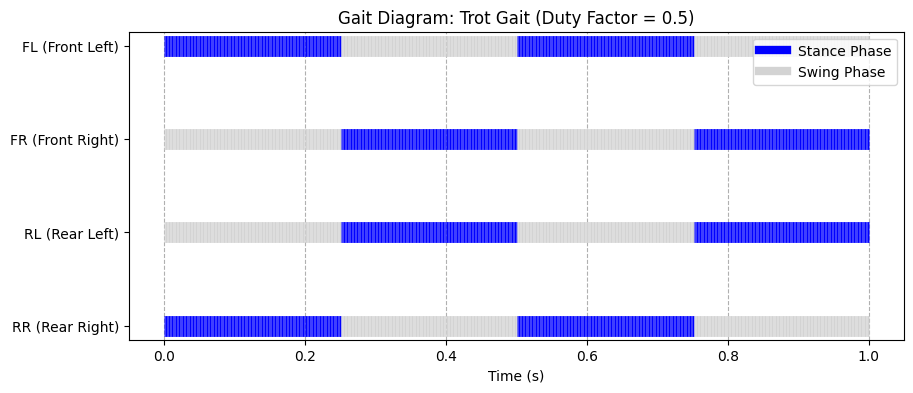

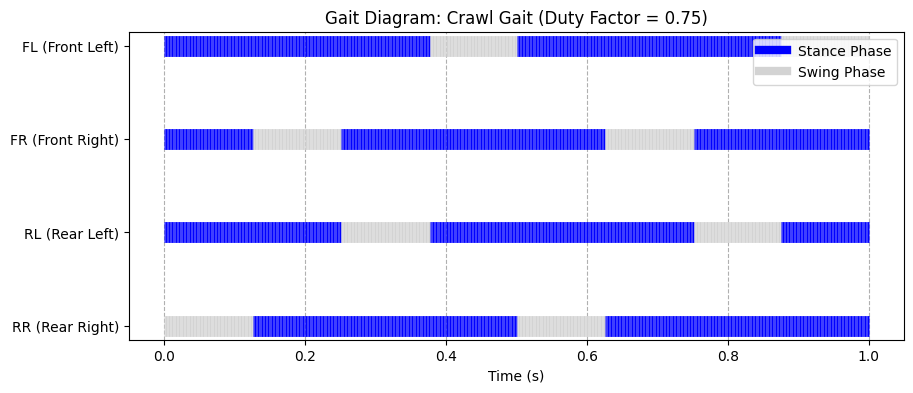

In [ ]:
class QuadrupedGaitScheduler:
    def __init__(self, T=1.0):
        self.T = T
        self.legs = ['FL (Front Left)', 'FR (Front Right)', 'RL (Rear Left)', 'RR (Rear Right)']

    def get_phase(self, t, offset):
        # Menghitung fase dari 0.0 hingga 1.0
        return ((t / self.T) + offset) % 1.0

    def plot_gait_diagram(self, duty_factor, offsets, title):
        time_steps = np.linspace(0, 2 * self.T, 500) # Plot untuk 2 siklus

        fig, ax = plt.subplots(figsize=(10, 4))
        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            # Stance (kaki di tanah) = 1, Swing (kaki di udara) = 0
            stance = np.where(phases < duty_factor, 1, 0)

            # Plotting diagram Gantt
            for t_idx in range(len(time_steps)-1):
                if stance[t_idx] == 1:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='blue', lw=15, solid_capstyle='butt')
                else:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='lightgray', lw=15, solid_capstyle='butt')

        ax.set_yticks([0, 1, 2, 3])
        ax.set_yticklabels(self.legs[::-1])
        ax.set_xlabel('Time (s)')
        ax.set_title(f'Gait Diagram: {title} (Duty Factor = {duty_factor})')
        ax.grid(axis='x', linestyle='--')

        # Legend custom
        custom_lines = [plt.Line2D([0], [0], color='blue', lw=6), plt.Line2D([0], [0], color='lightgray', lw=6)]
        ax.legend(custom_lines, ['Stance Phase', 'Swing Phase'], loc='upper right')

        plt.show()

# Inisialisasi scheduler
scheduler = QuadrupedGaitScheduler(T=0.5)

# 1. Trot Gait: Pasangan diagonal bergerak bersamaan
trot_offsets = [0.0, 0.5, 0.5, 0.0]  # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.5, offsets=trot_offsets, title='Trot Gait')

# 2. Crawl Gait: Gerak bergantian satu per satu, sangat stabil statis
crawl_offsets = [0.0, 0.5, 0.25, 0.75] # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.75, offsets=crawl_offsets, title='Crawl Gait')

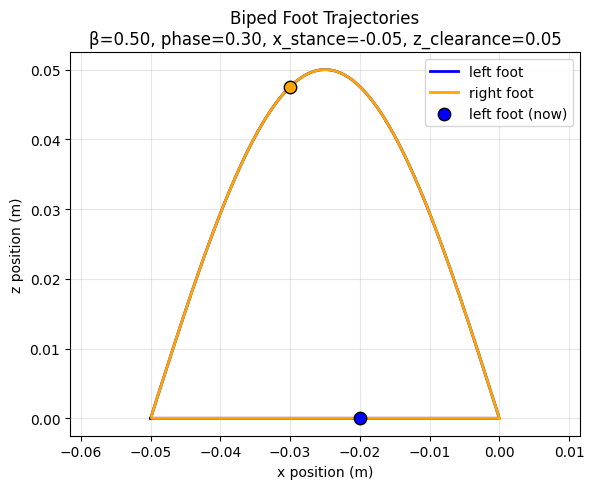

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def foot_position_cmd(phase, beta, x_stance=-0.05, x_lift=0.0,
                      z_ground=0.0, z_clearance=0.05):
    """Return desired (x, z) foot position for leg phase in [0,1)."""
    if phase < beta:  # stance
        t = phase / beta
        x = x_stance + (x_lift - x_stance) * t
        z = z_ground
    else:  # swing
        t = (phase - beta) / (1.0 - beta)
        x = x_lift + (x_stance - x_lift) * t
        z = z_clearance * np.sin(np.pi * t)
    return x, z

# ----- Editable parameters -----
beta = 0.5          # duty factor (stance fraction)
phase = 0.3         # current phase (0..1) to show instantaneous foot positions
x_stance = -0.05    # x position during stance (m)
x_lift = 0.0        # x position at lift-off / touch-down (m)
z_ground = 0.0      # ground height (m)
z_clearance = 0.05  # max foot height during swing (m)
# --------------------------------

T = 1.0  # period of one gait cycle (s)
t = np.linspace(0, T, 400)
phases = t / T  # 0 to 1

# Offsets for left and right foot (opposite phase)
offsets = {'left': 0.0, 'right': 0.5}

plt.figure(figsize=(6,5))
for leg, offset in offsets.items():
    xs, zs = [], []
    for ph in phases:
        x, z = foot_position_cmd((ph + offset) % 1.0,
                                 beta, x_stance, x_lift,
                                 z_ground, z_clearance)
        xs.append(x); zs.append(z)
    color = 'blue' if leg == 'left' else 'orange'
    plt.plot(xs, zs, label=f'{leg} foot', color=color, linewidth=2)

# Instantaneous positions at current phase
cur_xs, cur_zs = [], []
for leg, offset in offsets.items():
    ph_cur = (phase + offset) % 1.0
    x_cur, z_cur = foot_position_cmd(ph_cur, beta,
                                     x_stance, x_lift,
                                     z_ground, z_clearance)
    cur_xs.append(x_cur); cur_zs.append(z_cur)
    color = 'blue' if leg == 'left' else 'orange'
    plt.scatter([x_cur], [z_cur], color=color, s=80, zorder=5,
                edgecolors='k', label=f'{leg} foot (now)' if leg == 'left' else None)

plt.xlabel('x position (m)')
plt.ylabel('z position (m)')
plt.title('Biped Foot Trajectories\n'
          f'β={beta:.2f}, phase={phase:.2f}, x_stance={x_stance:.2f}, '
          f'z_clearance={z_clearance:.2f}')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 2. Assignment: Hexapod Tripod Gait Design

Sesuai materi perkuliahan minggu ini, hexapod dapat menggunakan *tripod gait* di mana 3 kaki membentuk fondasi segitiga yang stabil, secara bergantian (alternating triangles).

**Tugas Praktikum:**
1. Modifikasi kelas/fungsi di atas agar mampu menangani 6 kaki (L1, L2, L3, R1, R2, R3).
2. Buat matriks `offsets` dan tentukan *duty factor* yang tepat untuk *Tripod Gait*.
3. Plot diagram *gait*-nya dan verifikasi kelayakan stabilitasnya.
4. Tuliskan analisis Anda mengenai perbedaan stabilitas antara *Trot Quadruped* dengan *Tripod Hexapod* di sel *markdown* bawah.

---
**Catatan Implementasi Teknis Lanjutan:**
Nantinya saat Anda mengintegrasikan luaran *gait scheduler* ini ke simulasi skrip *forward/inverse kinematics* Anda, pastikan *coxa* dipaksa beroperasi konstan pada bidang XY. Selain itu, Anda harus menghapus keberadaan titik koordinat *base* dari matriks simulasi kakinya. Hal ini akan mencegah perhitungan matriks singular dan mempercepat konvergensi algoritma IK saat transisi fase *stance* ke *swing*.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Fungsi Perintah Posisi Langkah Kaki (X, Z)
def foot_position_cmd(phase, beta, x_stance=-0.05, x_lift=0.0,
                      z_ground=0.0, z_clearance=0.05):
    if phase < beta:  # Fase stance (menumpu di tanah)
        t = phase / beta
        x = x_stance + (x_lift - x_stance) * t
        z = z_ground
    else:  # Fase swing (melangkah di udara)
        t = (phase - beta) / (1.0 - beta)
        x = x_lift + (x_stance - x_lift) * t
        z = z_clearance * np.sin(np.pi * t)
    return x, z

In [ ]:
# 2. Kelas Gait Scheduler untuk Hexapod (6 Kaki)
class HexapodGaitScheduler:
    def __init__(self, T=1.0):
        self.T = T
        self.legs = ['L1', 'L2', 'L3', 'R1', 'R2', 'R3']

    def get_phase(self, t, offset):
        return ((t / self.T) + offset) % 1.0

    def plot_hexapod_gait(self, duty_factor, offsets, x_stance, x_lift, z_ground, z_clearance):
        time_steps = np.linspace(0, 2 * self.T, 500)
        num_legs = len(self.legs)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # --- PLOT BARIS 1: Diagram Gantt ---
        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            stance = np.where(phases < duty_factor, 1, 0)
            y_pos = (num_legs - 1) - i

            for t_idx in range(len(time_steps)-1):
                color = 'blue' if stance[t_idx] == 1 else 'lightgray'
                ax1.plot([time_steps[t_idx], time_steps[t_idx+1]], [y_pos, y_pos], color=color, lw=12, solid_capstyle='butt')

        ax1.set_yticks(range(num_legs))
        ax1.set_yticklabels(self.legs[::-1])
        ax1.set_xlabel('Waktu (s)')
        ax1.set_title(f'Hexapod Gantt Chart: Tripod Gait (β = {duty_factor})')
        ax1.grid(axis='x', linestyle='--')
        custom_lines = [plt.Line2D([0], [0], color='blue', lw=6), plt.Line2D([0], [0], color='lightgray', lw=6)]
        ax1.legend(custom_lines, ['Stance Phase', 'Swing Phase'], loc='upper right')

        # --- PLOT BARIS 2: Trajektori Berbentuk Titik-Titik (Scatter) ---
        t_cycle = np.linspace(0, self.T, 200) # Kembali menggunakan garis kontinu halus
        colors = ['red', 'green', 'magenta', 'orange', 'cyan', 'black']

        # Tentukan fase instan saat ini untuk simulasi posisi titik (misal: fase = 0.30)
        current_phase = 0.30

        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            xs, zs = [], []
            visual_z_offset = i * 0.005 # Offset visual vertikal agar lintasan antar kaki terpisah

            # 1. Gambar garis lintasan utuh (Garis Kontinu)
            for t_val in t_cycle:
                ph = self.get_phase(t_val, offset)
                x, z = foot_position_cmd(ph, duty_factor, x_stance, x_lift, z_ground, z_clearance)
                xs.append(x)
                zs.append(z + visual_z_offset)
            ax2.plot(xs, zs, color=colors[i], alpha=0.5, linewidth=2, zorder=1)

            # 2. Gambar SATU titik posisi kaki saat ini (Simulasi Real-time seperti Gambar Acuan)
            ph_now = (current_phase + offset) % 1.0
            x_now, z_now = foot_position_cmd(ph_now, duty_factor, x_stance, x_lift, z_ground, z_clearance)

            # Tambahkan lingkaran dengan tepi hitam (edgecolor='k') agar persis gambar acuan
            ax2.scatter([x_now], [z_now + visual_z_offset], color=colors[i], s=80,
                        edgecolors='k', zorder=5, label=f'Posisi {leg} (Sekarang)')

        ax2.set_xlabel('Posisi X (m)')
        ax2.set_ylabel('Posisi Z (m) [Disisipkan Offset Visual]')
        ax2.set_title(f'Trajektori Langkah Hexapod (Fase Saat Ini = {current_phase:.2f})')
        ax2.grid(True, alpha=0.3)
        # Meletakkan legenda di luar/bawah grafik agar rapi
        ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

        plt.tight_layout()
        plt.show()

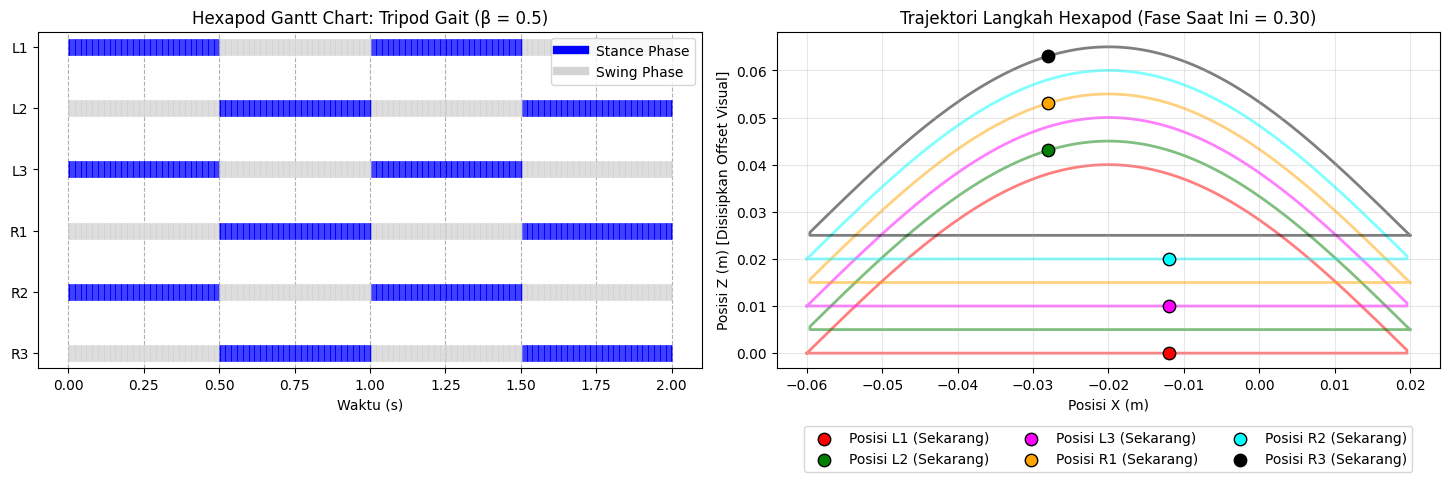

In [ ]:
# --- Inisialisasi Parameter Berdasarkan Ketentuan Tugas ---
beta_tripod = 0.5
hexapod_offsets = [0.0, 0.5, 0.0, 0.5, 0.0, 0.5] # Pola Tripod bergantian

# Setup geometri langkah
x_stance_val = -0.06
x_lift_val = 0.02
z_ground_val = 0.0
z_clearance_val = 0.04

# Jalankan plot
scheduler = HexapodGaitScheduler(T=1.0)
scheduler.plot_hexapod_gait(duty_factor=beta_tripod, offsets=hexapod_offsets,
                            x_stance=x_stance_val, x_lift=x_lift_val,
                            z_ground=z_ground_val, z_clearance=z_clearance_val)

### Analisis Perbedaan Stabilitas: Trot Quadruped vs. Tripod Hexapod

Berdasarkan hasil visualisasi koordinasi fase gerak (*gait scheduler*) dan kurva trajektori langkah kaki, terdapat perbedaan karakteristik mekanika stabilitas yang signifikan antara *Trot Gait* (Quadruped) dan *Tripod Gait* (Hexapod):

1. **Tripod Gait pada Hexapod (Stabilitas Statis - Static Stability):**
   * **Mekanisme Poligon:** Pola tripod membagi enam kaki menjadi dua kelompok segitiga penumpu (Kelompok 1: `L1, L3, R2` dan Kelompok 2: `L2, R1, R3`).
   * **Kelebihan Stabilitas:** Sepanjang siklus berjalan dengan $\beta = 0.5$, robot akan selalu ditumpu oleh 3 kaki yang membentuk formasi segitiga stabil (*support polygon*). Karena proyeksi titik koordinat Pusat Massa (*Center of Mass* - CoM) robot selalu berada di dalam area poligon segitiga tumpuan ini, hexapod memiliki tingkat stabilitas statis yang sempurna. Robot dapat mendadak berhenti atau mempertahankan posisi statis di tengah-tengah langkah tanpa risiko terjungkir.

2. **Trot Gait pada Quadruped (Stabilitas Dinamis - Dynamic Stability):**
   * **Mekanisme Poligon:** Pola trot menggerakkan kaki quadruped secara berpasangan diagonal (misal: Depan Kiri-Belakang Kanan berayun, sementara Depan Kanan-Belakang Kiri menumpu).
   * **Keterbatasan Stabilitas:** Saat fase melangkah dengan $\beta = 0.5$, tumpuan robot di tanah hanya berupa dua titik kontak kaki yang membentuk sebuah garis lurus (*support line*). Karena area poligon tumpuan lurus tersebut tidak memiliki ruang dua dimensi, robot quadruped *tidak stabil secara statis* saat berjalan. Robot harus mengandalkan keseimbangan dinamis (*dynamic stability*)—yaitu terus bergerak maju memanfaatkan momentum inersia agar posisinya tetap tegak, mirip seperti prinsip menyeimbangkan sepeda yang melaju.